In [2]:
import pandas as pd


In [3]:

# 1. Load the CSV data
df = pd.read_csv('Fertilizer Guide Book.csv')
print("Original Columns:\n", df.columns.tolist())
df.head()


Original Columns:
 ['Crop', 'N/K Test Value', 'Urea', 'MoP', 'P/S Test Value', 'TSP/DAP Olsen Method', 'TSP/DAP Bray & Kurtz', 'Gypsum', 'Zn Test Value', 'Zn Sulphate Hepta Hydrate', 'Equivalent Gypsum']


,Crop,N/K Test Value,Urea,MoP,P/S Test Value,TSP/DAP Olsen Method,TSP/DAP Bray & Kurtz,Gypsum,Zn Test Value,Zn Sulphate Hepta Hydrate,Equivalent Gypsum
0,Boro Rice(BRI 29),0.00,2109,1231.0,0,648.0,648.0,539,0.00,75.0,44.0
1,Boro Rice(BRI 29),0.01,2050,1190.0,1,621.0,605.0,524,0.05,72.0,42.0
2,Boro Rice(BRI 29),0.02,1991,1149.0,2,594.0,561.0,509,0.10,69.0,41.0
3,Boro Rice(BRI 29),0.03,1933,1108.0,3,567.0,518.0,494,0.15,67.0,39.0
4,Boro Rice(BRI 29),0.04,1874,1067.0,4,540.0,475.0,479,0.20,64.0,37.0


In [4]:
# 2. Remove specified columns: Gypsum, Zn Test Value, Zn Sulphate Hepta Hydrate, Equivalent Gypsum
columns_to_drop = ['Gypsum', 'Zn Test Value', 'Zn Sulphate Hepta Hydrate', 'Equivalent Gypsum', 'TSP/DAP Bray & Kurtz']
df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')

print("Columns after dropping specified columns:\n", df_cleaned.columns.tolist())
df_cleaned.head()


Columns after dropping specified columns:
 ['Crop', 'N/K Test Value', 'Urea', 'MoP', 'P/S Test Value', 'TSP/DAP Olsen Method']


,Crop,N/K Test Value,Urea,MoP,P/S Test Value,TSP/DAP Olsen Method
0,Boro Rice(BRI 29),0.00,2109,1231.0,0,648.0
1,Boro Rice(BRI 29),0.01,2050,1190.0,1,621.0
2,Boro Rice(BRI 29),0.02,1991,1149.0,2,594.0
3,Boro Rice(BRI 29),0.03,1933,1108.0,3,567.0
4,Boro Rice(BRI 29),0.04,1874,1067.0,4,540.0


In [30]:
# 3. Rename columns to N, P, K
# Depending on your use case, N, P, K can refer to either the Fertilizer amounts or the Soil Test Values.

# Interpretation A: N, P, K refer to the Fertilizers (Urea = N, TSP/DAP Olsen = P, MoP = K)
df_fertilizers = df_cleaned.rename(columns={
    'Urea': 'urea',
    'TSP/DAP Olsen Method': 'tsP',
    'P/S Test Value': 'p',
    'N/K Test Value': 'n/k'
})

# Reorder columns to place 'p' just after 'n/k'
df_fertilizers = df_fertilizers[['Crop', 'n/k', 'p', 'urea', 'MoP', 'tsP']]

print("Interpretation A (Fertilizers as N, P, K) columns:\n", df_fertilizers.columns.tolist())
df_fertilizers.head()

Interpretation A (Fertilizers as N, P, K) columns:
 ['Crop', 'n/k', 'p', 'urea', 'MoP', 'tsP']


,Crop,n/k,p,urea,MoP,tsP
0,Boro Rice(BRI 29),0.00,0,2109,1231.0,648.0
1,Boro Rice(BRI 29),0.01,1,2050,1190.0,621.0
2,Boro Rice(BRI 29),0.02,2,1991,1149.0,594.0
3,Boro Rice(BRI 29),0.03,3,1933,1108.0,567.0
4,Boro Rice(BRI 29),0.04,4,1874,1067.0,540.0


In [33]:
df_fertilizers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Crop    333 non-null    object 
 1   n/k     333 non-null    float64
 2   p       333 non-null    int64  
 3   urea    333 non-null    int64  
 4   MoP     333 non-null    float64
 5   tsP     333 non-null    float64
dtypes: float64(3), int64(2), object(1)
memory usage: 15.7+ KB


In [32]:
df_fertilizers.fillna(0, inplace=True)
df_fertilizers.head()

,Crop,n/k,p,urea,MoP,tsP
0,Boro Rice(BRI 29),0.00,0,2109,1231.0,648.0
1,Boro Rice(BRI 29),0.01,1,2050,1190.0,621.0
2,Boro Rice(BRI 29),0.02,2,1991,1149.0,594.0
3,Boro Rice(BRI 29),0.03,3,1933,1108.0,567.0
4,Boro Rice(BRI 29),0.04,4,1874,1067.0,540.0


In [40]:
df_fertilizers.to_csv("fertilizers_nonzero.csv", index=False)

In [41]:
df_fertilizers.isnull().sum()

Crop    0
n/k     0
p       0
urea    0
MoP     0
tsP     0
dtype: int64

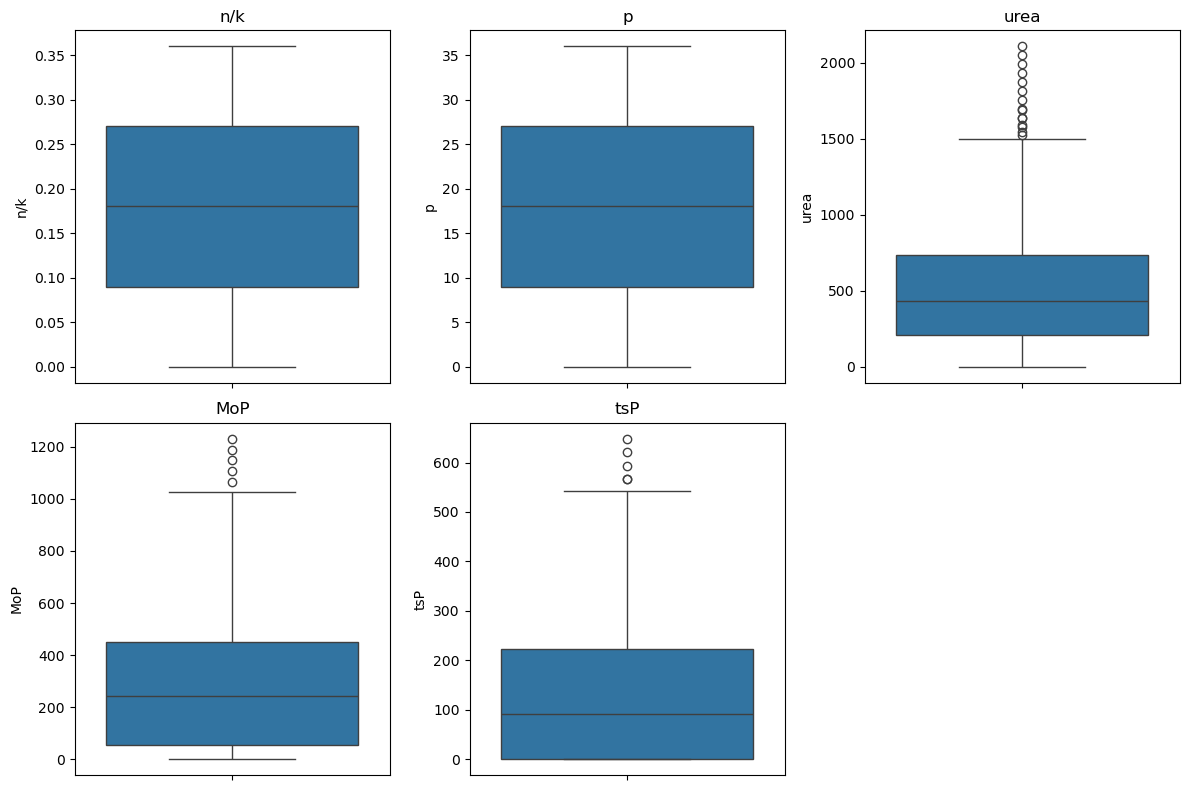

In [48]:
from seaborn import boxplot
import matplotlib.pyplot as plt

numeric_cols_plot = [col for col in numeric_cols if col != 'Crop_Label']
n = len(numeric_cols_plot)
ncols = 3
nrows = (n + ncols - 1) // ncols
plt.figure(figsize=(ncols * 4, nrows * 4))

for i, col in enumerate(numeric_cols_plot, 1):
    plt.subplot(nrows, ncols, i)
    boxplot(data=df_fertilizers, y=col, ax=plt.gca())
    plt.title(col)

plt.tight_layout()
plt.show()

In [50]:
# 4. Categorical encoding for crop type using One-Hot Encoding
df_fertilizers_onehot = pd.get_dummies(df_fertilizers, columns=['Crop'], dtype=int)

print("One-hot encoded columns:\n", df_fertilizers_onehot.columns.tolist())

# Save to CSV
df_fertilizers_onehot.to_csv("df_fertilizers_onehot.csv", index=False)
df_fertilizers_onehot.head()

One-hot encoded columns:
 ['n/k', 'p', 'urea', 'MoP', 'tsP', 'Crop_Aus(BRI 27)', 'Crop_Aus(BRI 42)', 'Crop_B. Aman', 'Crop_Boro Rice(BRI 28)', 'Crop_Boro Rice(BRI 29)', 'Crop_Boro Rice(BRI 36)', 'Crop_T. Aman(BRRI 25)', 'Crop_T. Aman(BRRI 51)', 'Crop_T. Aman(Binadhan 9)']


,n/k,p,urea,MoP,tsP,Crop_Aus(BRI 27),Crop_Aus(BRI 42),Crop_B. Aman,Crop_Boro Rice(BRI 28),Crop_Boro Rice(BRI 29),Crop_Boro Rice(BRI 36),Crop_T. Aman(BRRI 25),Crop_T. Aman(BRRI 51),Crop_T. Aman(Binadhan 9)
0,0.00,0,2109,1231.0,648.0,0,0,0,0,1,0,0,0,0
1,0.01,1,2050,1190.0,621.0,0,0,0,0,1,0,0,0,0
2,0.02,2,1991,1149.0,594.0,0,0,0,0,1,0,0,0,0
3,0.03,3,1933,1108.0,567.0,0,0,0,0,1,0,0,0,0
4,0.04,4,1874,1067.0,540.0,0,0,0,0,1,0,0,0,0


In [51]:
from sklearn.preprocessing import MinMaxScaler

# 5. Normalization for continuous feature columns
# We only normalize input features ('n/k' and 'p') and NOT the target columns ('urea', 'MoP', 'tsP')
# One-hot encoded crop type columns are already binary (0 or 1), so they don't need scaling.

features_to_normalize = ['n/k', 'p']
scaler = MinMaxScaler()

df_normalized = df_fertilizers_onehot.copy()
df_normalized[features_to_normalize] = scaler.fit_transform(df_fertilizers_onehot[features_to_normalize])

print("Features normalized using MinMaxScaler (showing 'n/k' and 'p'):")
print(df_normalized[features_to_normalize].head())

# Save normalized dataset to CSV
df_normalized.to_csv("df_fertilizers_normalized.csv", index=False)

Features normalized using MinMaxScaler (showing 'n/k' and 'p'):
        n/k         p
0  0.000000  0.000000
1  0.027778  0.027778
2  0.055556  0.055556
3  0.083333  0.083333
4  0.111111  0.111111


In [52]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

df = pd.read_csv("df_fertilizers_normalized.csv")

targets = ["urea", "MoP", "tsP"]
X = df.drop(columns=targets)
y = df[targets]                      # multi-output: 3 columns at once

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# --- Baseline: Linear Regression (data is piecewise-linear, so this is a strong baseline)
lin = LinearRegression().fit(X_train, y_train)

# --- Main: Random Forest (handles multi-output natively, no wrapper needed)
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1).fit(X_train, y_train)

def report(name, model):
    pred = model.predict(X_test)
    print(f"\n=== {name} ===")
    for i, t in enumerate(targets):
        r2  = r2_score(y_test[t], pred[:, i])
        mae = mean_absolute_error(y_test[t], pred[:, i])
        rmse= root_mean_squared_error(y_test[t], pred[:, i])
        print(f"{t:6s}  R2={r2:.4f}  MAE={mae:7.2f}  RMSE={rmse:7.2f}")

report("Linear Regression", lin)
report("Random Forest", rf)


=== Linear Regression ===
urea    R2=0.8878  MAE= 122.61  RMSE= 162.42
MoP     R2=0.8883  MAE=  72.06  RMSE=  96.26
tsP     R2=0.8401  MAE=  51.33  RMSE=  63.86

=== Random Forest ===
urea    R2=0.9977  MAE=  17.89  RMSE=  23.22
MoP     R2=0.9979  MAE=   9.80  RMSE=  13.30
tsP     R2=0.9963  MAE=   6.25  RMSE=   9.75


In [53]:
import joblib

# 6. Save the trained Random Forest model and the fitted scaler for future prediction use
# We save the fitted MinMaxScaler as well because any new input features must be scaled the exact same way before making predictions.

joblib.dump(rf, 'fertilizer_rf_model.pkl')
joblib.dump(scaler, 'fertilizer_scaler.pkl')

print("Model saved to 'fertilizer_rf_model.pkl'")
print("Scaler saved to 'fertilizer_scaler.pkl'")

Model saved to 'fertilizer_rf_model.pkl'
Scaler saved to 'fertilizer_scaler.pkl'
